<a href="https://colab.research.google.com/github/F1ameX/Modern-Methods-of-Deep-Machine-Learning/blob/main/6_autoencoders/6_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import random
import time
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from tqdm.auto import tqdm

In [2]:
SEED = 52
DATASET_NAME = "MNIST"
DATA_ROOT = "./data"

QUICK_RUN = False

BATCH_SIZE = 128
TRAIN_SIZE = 12_000 if not QUICK_RUN else 2_000
VAL_SIZE = 2_000 if not QUICK_RUN else 500
TEST_SIZE = 2_000 if not QUICK_RUN else 500

BASE_EPOCHS = 4 if not QUICK_RUN else 1
LONG_EPOCHS = 8 if not QUICK_RUN else 2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = DEVICE == "cuda"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("DEVICE:", DEVICE)
print("DATASET:", DATASET_NAME)
print("TRAIN/VAL/TEST:", TRAIN_SIZE, VAL_SIZE, TEST_SIZE)

DEVICE: cuda
DATASET: MNIST
TRAIN/VAL/TEST: 12000 2000 2000


In [9]:
DATASETS = {
    "MNIST": datasets.MNIST,
    "FashionMNIST": datasets.FashionMNIST,
}

if DATASET_NAME not in DATASETS:
    raise ValueError(f"Unknown dataset: {DATASET_NAME}. Use one of {list(DATASETS)}")

transform = transforms.ToTensor()
DatasetClass = DATASETS[DATASET_NAME]

train_full = DatasetClass(DATA_ROOT, train=True, download=True, transform=transform)
test_full = DatasetClass(DATA_ROOT, train=False, download=True, transform=transform)

rng = torch.Generator().manual_seed(SEED)
train_indices = torch.randperm(len(train_full), generator=rng)[: TRAIN_SIZE + VAL_SIZE].tolist()
test_indices = torch.randperm(len(test_full), generator=rng)[:TEST_SIZE].tolist()

train_dataset = Subset(train_full, train_indices[:TRAIN_SIZE])
val_dataset = Subset(train_full, train_indices[TRAIN_SIZE: TRAIN_SIZE + VAL_SIZE])
test_dataset = Subset(test_full, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)

sample_batch, sample_labels = next(iter(test_loader))
print(sample_batch.shape, sample_labels[:10].tolist())

torch.Size([128, 1, 28, 28]) [8, 7, 4, 0, 5, 4, 3, 4, 3, 6]


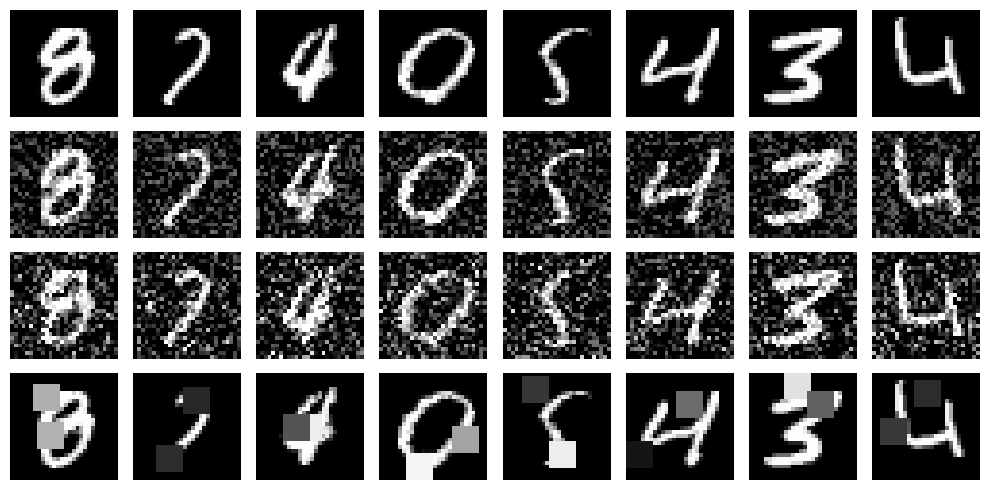

In [10]:
@dataclass(frozen=True)
class NoiseConfig:
    kind: str
    level: float = 0.0
    std: float = 0.0
    num_spots: int = 0
    spot_size: int = 6
    spot_value: str = "random"


def noise_label(cfg: NoiseConfig) -> str:
    if cfg.kind == "uniform":
        return f"uniform +/-{cfg.level}"
    if cfg.kind == "gaussian":
        return f"gaussian sigma={cfg.std}"
    if cfg.kind == "spots":
        return f"spots {cfg.num_spots}x{cfg.spot_size}"
    if cfg.kind == "none":
        return "clean"
    return cfg.kind


def add_noise(x: torch.Tensor, cfg: NoiseConfig) -> torch.Tensor:
    if cfg.kind == "none":
        return x

    if cfg.kind == "uniform":
        noisy = x + (torch.rand_like(x) * 2.0 - 1.0) * cfg.level
        return noisy.clamp(0.0, 1.0)

    if cfg.kind == "gaussian":
        noisy = x + torch.randn_like(x) * cfg.std
        return noisy.clamp(0.0, 1.0)

    if cfg.kind == "spots":
        noisy = x.clone()
        batch_size, channels, height, width = noisy.shape
        size = min(cfg.spot_size, height, width)

        for i in range(batch_size):
            for _ in range(cfg.num_spots):
                top = torch.randint(0, height - size + 1, (1,), device=x.device).item()
                left = torch.randint(0, width - size + 1, (1,), device=x.device).item()

                if cfg.spot_value == "black":
                    value = 0.0
                elif cfg.spot_value == "white":
                    value = 1.0
                else:
                    value = torch.rand(1, device=x.device).item()

                noisy[i, :, top: top + size, left: left + size] = value

        return noisy.clamp(0.0, 1.0)

    raise ValueError(f"Unknown noise kind: {cfg.kind}")


NOISE_CONFIGS = {
    "uniform": NoiseConfig(kind="uniform", level=0.45),
    "gaussian": NoiseConfig(kind="gaussian", std=0.35),
    "spots": NoiseConfig(kind="spots", num_spots=2, spot_size=7, spot_value="random"),
}


def plot_tensor_grid(rows: List[Tuple[str, torch.Tensor]], n: int = 8, figsize_per_image: float = 1.25):
    fig, axes = plt.subplots(len(rows), n, figsize=(figsize_per_image * n, figsize_per_image * len(rows)))
    if len(rows) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (title, images) in enumerate(rows):
        images = images[:n].detach().cpu()
        for col_idx in range(n):
            ax = axes[row_idx, col_idx]
            ax.imshow(images[col_idx].squeeze(0), cmap="gray", vmin=0.0, vmax=1.0)
            ax.axis("off")
            if col_idx == 0:
                ax.set_ylabel(title, rotation=0, labelpad=44, va="center")

    plt.tight_layout()
    plt.show()


clean_examples = sample_batch[:8]
noise_rows = [("clean", clean_examples)]
for name, cfg in NOISE_CONFIGS.items():
    torch.manual_seed(SEED)
    noise_rows.append((name, add_noise(clean_examples, cfg)))

plot_tensor_grid(noise_rows, n=8)

In [11]:
class DenseAutoencoder(nn.Module):
    def __init__(self, input_dim: int = 28 * 28, hidden_dims: Tuple[int, ...] = (512, 256), latent_dim: int = 32, dropout: float = 0.0):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = tuple(hidden_dims)
        self.latent_dim = latent_dim

        encoder_layers: List[nn.Module] = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            encoder_layers.append(nn.ReLU())
            if dropout > 0.0:
                encoder_layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        encoder_layers.append(nn.Linear(prev_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers: List[nn.Module] = []
        prev_dim = latent_dim
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            decoder_layers.append(nn.ReLU())
            if dropout > 0.0:
                decoder_layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        decoder_layers.append(nn.Sigmoid())
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decode(self.encode(x))


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model_demo = DenseAutoencoder(hidden_dims=(512, 256), latent_dim=32)
print(model_demo)
print("Trainable parameters:", count_parameters(model_demo))

DenseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)
Trainable parameters: 1083696


In [12]:
def psnr_from_mse(mse: float, max_value: float = 1.0) -> float:
    mse = max(float(mse), 1e-12)
    return 10.0 * math.log10((max_value ** 2) / mse)


def ssim_score(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    x = x.flatten(start_dim=1)
    y = y.flatten(start_dim=1)

    c1 = 0.01 ** 2
    c2 = 0.03 ** 2

    mu_x = x.mean(dim=1)
    mu_y = y.mean(dim=1)
    var_x = x.var(dim=1, unbiased=False)
    var_y = y.var(dim=1, unbiased=False)
    cov_xy = ((x - mu_x[:, None]) * (y - mu_y[:, None])).mean(dim=1)

    numerator = (2 * mu_x * mu_y + c1) * (2 * cov_xy + c2)
    denominator = (mu_x.pow(2) + mu_y.pow(2) + c1) * (var_x + var_y + c2)
    return (numerator / denominator.clamp_min(1e-12)).mean()


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, noise_cfg: NoiseConfig, device: str = DEVICE) -> Dict[str, float]:
    model.eval()

    total_pixels = 0
    noisy_sse = 0.0
    denoise_sse = 0.0
    clean_sse = 0.0
    denoise_ssim_sum = 0.0
    clean_ssim_sum = 0.0
    total_images = 0

    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_noise(clean, noise_cfg)

        denoised = model(noisy)
        clean_reconstructed = model(clean)

        pixels = clean.numel()
        batch_size = clean.size(0)

        noisy_sse += F.mse_loss(noisy, clean, reduction="sum").item()
        denoise_sse += F.mse_loss(denoised, clean, reduction="sum").item()
        clean_sse += F.mse_loss(clean_reconstructed, clean, reduction="sum").item()
        denoise_ssim_sum += ssim_score(denoised, clean).item() * batch_size
        clean_ssim_sum += ssim_score(clean_reconstructed, clean).item() * batch_size

        total_pixels += pixels
        total_images += batch_size

    noisy_mse = noisy_sse / total_pixels
    denoise_mse = denoise_sse / total_pixels
    clean_mse = clean_sse / total_pixels

    return {
        "noisy_mse": noisy_mse,
        "noisy_psnr": psnr_from_mse(noisy_mse),
        "denoise_mse": denoise_mse,
        "denoise_psnr": psnr_from_mse(denoise_mse),
        "denoise_ssim": denoise_ssim_sum / total_images,
        "clean_mse": clean_mse,
        "clean_psnr": psnr_from_mse(clean_mse),
        "clean_ssim": clean_ssim_sum / total_images,
        "mse_gain_%": 100.0 * (noisy_mse - denoise_mse) / max(noisy_mse, 1e-12),
    }


def train_autoencoder(
    noise_cfg: NoiseConfig,
    hidden_dims: Tuple[int, ...],
    latent_dim: int,
    epochs: int,
    lr: float,
    device: str = DEVICE,
) -> Tuple[DenseAutoencoder, pd.DataFrame, float]:
    model = DenseAutoencoder(hidden_dims=hidden_dims, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []

    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        total_pixels = 0

        progress = tqdm(train_loader, desc=f"epoch {epoch}/{epochs} | {noise_label(noise_cfg)}", leave=False)
        for clean, _ in progress:
            clean = clean.to(device)
            noisy = add_noise(clean, noise_cfg)

            optimizer.zero_grad(set_to_none=True)
            reconstructed = model(noisy)
            loss = criterion(reconstructed, clean)
            loss.backward()
            optimizer.step()

            train_loss_sum += F.mse_loss(reconstructed.detach(), clean, reduction="sum").item()
            total_pixels += clean.numel()
            progress.set_postfix(train_mse=train_loss_sum / total_pixels)

        train_mse = train_loss_sum / total_pixels
        val_metrics = evaluate_model(model, val_loader, noise_cfg, device=device)

        history.append({
            "epoch": epoch,
            "train_mse": train_mse,
            "val_denoise_mse": val_metrics["denoise_mse"],
            "val_denoise_psnr": val_metrics["denoise_psnr"],
            "val_clean_mse": val_metrics["clean_mse"],
        })

    train_time = time.perf_counter() - start_time
    return model, pd.DataFrame(history), train_time

In [13]:
BASE_HIDDEN = (512, 256)
BASE_LATENT = 32
BASE_LR = 1e-3
BASE_NOISE = NOISE_CONFIGS["gaussian"]

ARCHITECTURES = {
    "shallow_256": (256,),
    "medium_512_256": (512, 256),
    "deep_512_256_128": (512, 256, 128),
    "wide_768_384": (768, 384),
}

experiment_plan = []

for noise_name, cfg in NOISE_CONFIGS.items():
    experiment_plan.append({
        "study": "noise_type",
        "experiment": noise_name,
        "noise_cfg": cfg,
        "hidden_dims": BASE_HIDDEN,
        "latent_dim": BASE_LATENT,
        "epochs": BASE_EPOCHS,
        "lr": BASE_LR,
    })

for latent_dim in [8, 16, 32, 64]:
    experiment_plan.append({
        "study": "latent_dim",
        "experiment": f"latent_{latent_dim}",
        "noise_cfg": BASE_NOISE,
        "hidden_dims": BASE_HIDDEN,
        "latent_dim": latent_dim,
        "epochs": BASE_EPOCHS,
        "lr": BASE_LR,
    })

for architecture_name, hidden_dims in ARCHITECTURES.items():
    experiment_plan.append({
        "study": "architecture",
        "experiment": architecture_name,
        "noise_cfg": BASE_NOISE,
        "hidden_dims": hidden_dims,
        "latent_dim": BASE_LATENT,
        "epochs": BASE_EPOCHS,
        "lr": BASE_LR,
    })

for epochs, lr in [(BASE_EPOCHS, 3e-4), (BASE_EPOCHS, 1e-3), (BASE_EPOCHS, 3e-3), (LONG_EPOCHS, 1e-3)]:
    experiment_plan.append({
        "study": "hyperparameters",
        "experiment": f"epochs_{epochs}_lr_{lr:g}",
        "noise_cfg": BASE_NOISE,
        "hidden_dims": BASE_HIDDEN,
        "latent_dim": BASE_LATENT,
        "epochs": epochs,
        "lr": lr,
    })

pd.DataFrame([
    {
        "study": item["study"],
        "experiment": item["experiment"],
        "noise": noise_label(item["noise_cfg"]),
        "hidden_dims": item["hidden_dims"],
        "latent_dim": item["latent_dim"],
        "epochs": item["epochs"],
        "lr": item["lr"],
    }
    for item in experiment_plan
])

,study,experiment,noise,hidden_dims,latent_dim,epochs,lr
0,noise_type,uniform,uniform +/-0.45,"(512, 256)",32,4,0.0010
1,noise_type,gaussian,gaussian sigma=0.35,"(512, 256)",32,4,0.0010
2,noise_type,spots,spots 2x7,"(512, 256)",32,4,0.0010
3,latent_dim,latent_8,gaussian sigma=0.35,"(512, 256)",8,4,0.0010
4,latent_dim,latent_16,gaussian sigma=0.35,"(512, 256)",16,4,0.0010
5,latent_dim,latent_32,gaussian sigma=0.35,"(512, 256)",32,4,0.0010
6,latent_dim,latent_64,gaussian sigma=0.35,"(512, 256)",64,4,0.0010
7,architecture,shallow_256,gaussian sigma=0.35,"(256,)",32,4,0.0010
8,architecture,medium_512_256,gaussian sigma=0.35,"(512, 256)",32,4,0.0010
9,architecture,deep_512_256_128,gaussian sigma=0.35,"(512, 256, 128)",32,4,0.0010


In [14]:
ARTIFACTS: Dict[str, Dict] = {}


def make_run_id(noise_cfg: NoiseConfig, hidden_dims: Tuple[int, ...], latent_dim: int, epochs: int, lr: float) -> str:
    hidden_part = "x".join(map(str, hidden_dims))
    return f"{noise_label(noise_cfg)}|h={hidden_part}|z={latent_dim}|e={epochs}|lr={lr:g}"


def run_experiment(item: Dict) -> Dict:
    noise_cfg = item["noise_cfg"]
    hidden_dims = tuple(item["hidden_dims"])
    latent_dim = int(item["latent_dim"])
    epochs = int(item["epochs"])
    lr = float(item["lr"])
    run_id = make_run_id(noise_cfg, hidden_dims, latent_dim, epochs, lr)

    if run_id not in ARTIFACTS:
        print(f"Training: {run_id}")
        model, history, train_time = train_autoencoder(
            noise_cfg=noise_cfg,
            hidden_dims=hidden_dims,
            latent_dim=latent_dim,
            epochs=epochs,
            lr=lr,
        )
        test_metrics = evaluate_model(model, test_loader, noise_cfg)
        ARTIFACTS[run_id] = {
            "model": model,
            "history": history,
            "train_time_sec": train_time,
            "test_metrics": test_metrics,
            "noise_cfg": noise_cfg,
            "hidden_dims": hidden_dims,
            "latent_dim": latent_dim,
            "epochs": epochs,
            "lr": lr,
        }
    else:
        print(f"Using cache: {run_id}")

    artifact = ARTIFACTS[run_id]
    metrics = artifact["test_metrics"]

    return {
        "study": item["study"],
        "experiment": item["experiment"],
        "run_id": run_id,
        "noise": noise_label(noise_cfg),
        "hidden_dims": str(hidden_dims),
        "latent_dim": latent_dim,
        "epochs": epochs,
        "lr": lr,
        "params": count_parameters(artifact["model"]),
        "train_time_sec": artifact["train_time_sec"],
        **metrics,
    }


rows = []
for item in experiment_plan:
    rows.append(run_experiment(item))

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values(["study", "denoise_mse", "clean_mse"]).reset_index(drop=True)

metric_cols = [
    "study", "experiment", "noise", "hidden_dims", "latent_dim", "epochs", "lr", "params",
    "noisy_mse", "denoise_mse", "mse_gain_%", "denoise_psnr", "denoise_ssim",
    "clean_mse", "clean_psnr", "train_time_sec",
]

results_df[metric_cols].style.format({
    "lr": "{:.0e}",
    "params": "{:,}",
    "noisy_mse": "{:.5f}",
    "denoise_mse": "{:.5f}",
    "mse_gain_%": "{:.1f}",
    "denoise_psnr": "{:.2f}",
    "denoise_ssim": "{:.3f}",
    "clean_mse": "{:.5f}",
    "clean_psnr": "{:.2f}",
    "train_time_sec": "{:.1f}",
}).background_gradient(subset=["denoise_psnr", "denoise_ssim", "mse_gain_%"], cmap="Greens")

Training: uniform +/-0.45|h=512x256|z=32|e=4|lr=0.001


epoch 1/4 | uniform +/-0.45:   0%|          | 0/94 [00:00<?, ?it/s]

epoch 2/4 | uniform +/-0.45:   0%|          | 0/94 [00:00<?, ?it/s]

epoch 3/4 | uniform +/-0.45:   0%|          | 0/94 [00:00<?, ?it/s]

epoch 4/4 | uniform +/-0.45:   0%|          | 0/94 [00:00<?, ?it/s]

...

epoch 5/8 | gaussian sigma=0.35:   0%|          | 0/94 [00:00<?, ?it/s]

epoch 6/8 | gaussian sigma=0.35:   0%|          | 0/94 [00:00<?, ?it/s]

epoch 7/8 | gaussian sigma=0.35:   0%|          | 0/94 [00:00<?, ?it/s]

epoch 8/8 | gaussian sigma=0.35:   0%|          | 0/94 [00:00<?, ?it/s]

,study,experiment,noise,hidden_dims,latent_dim,epochs,lr,params,noisy_mse,denoise_mse,mse_gain_%,denoise_psnr,denoise_ssim,clean_mse,clean_psnr,train_time_sec
0,architecture,shallow_256,gaussian sigma=0.35,"(256,)",32,4,1e-03,"419,120",0.06254,0.02858,54.3,15.44,0.804,0.04655,13.32,7.5
1,architecture,wide_768_384,gaussian sigma=0.35,"(768, 384)",32,4,1e-03,"1,821,744",0.06257,0.02975,52.5,15.27,0.802,0.04024,13.95,8.2
2,architecture,medium_512_256,gaussian sigma=0.35,"(512, 256)",32,4,1e-03,"1,083,696",0.06244,0.03293,47.3,14.82,0.773,0.04194,13.77,9.5
3,architecture,deep_512_256_128,gaussian sigma=0.35,"(512, 256, 128)",32,4,1e-03,"1,141,296",0.06229,0.04486,28.0,13.48,0.669,0.04651,13.32,8.2
4,hyperparameters,epochs_8_lr_0.001,gaussian sigma=0.35,"(512, 256)",32,8,1e-03,"1,083,696",0.06235,0.02445,60.8,16.12,0.839,0.03330,14.78,16.2
5,hyperparameters,epochs_4_lr_0.003,gaussian sigma=0.35,"(512, 256)",32,4,3e-03,"1,083,696",0.06244,0.03101,50.3,15.08,0.793,0.03851,14.14,8.3
6,hyperparameters,epochs_4_lr_0.001,gaussian sigma=0.35,"(512, 256)",32,4,1e-03,"1,083,696",0.06244,0.03293,47.3,14.82,0.773,0.04194,13.77,9.5
7,hyperparameters,epochs_4_lr_0.0003,gaussian sigma=0.35,"(512, 256)",32,4,3e-04,"1,083,696",0.06247,0.04910,21.4,13.09,0.632,0.06103,12.14,7.3
8,latent_dim,latent_16,gaussian sigma=0.35,"(512, 256)",16,4,1e-03,"1,075,488",0.06260,0.03249,48.1,14.88,0.773,0.04037,13.94,8.2
9,latent_dim,latent_8,gaussian sigma=0.35,"(512, 256)",8,4,1e-03,"1,071,384",0.06235,0.03262,47.7,14.86,0.780,0.04064,13.91,7.5


In [15]:
def show_factor_table(df: pd.DataFrame, study: str):
    cols = ["experiment", "noise", "hidden_dims", "latent_dim", "epochs", "lr", "denoise_mse", "denoise_psnr", "denoise_ssim", "clean_mse", "mse_gain_%"]
    part = df[df["study"] == study].sort_values("denoise_mse")
    print(f"Study: {study}")
    display(part[cols].style.format({
        "lr": "{:.0e}",
        "denoise_mse": "{:.5f}",
        "denoise_psnr": "{:.2f}",
        "denoise_ssim": "{:.3f}",
        "clean_mse": "{:.5f}",
        "mse_gain_%": "{:.1f}",
    }).background_gradient(subset=["denoise_psnr", "denoise_ssim", "mse_gain_%"], cmap="Greens"))


for study in ["noise_type", "latent_dim", "architecture", "hyperparameters"]:
    show_factor_table(results_df, study)


def print_study_conclusion(df: pd.DataFrame, study: str):
    part = df[df["study"] == study].sort_values("denoise_mse")
    best = part.iloc[0]
    worst = part.iloc[-1]
    print(f"{study}: лучший вариант - {best['experiment']} ({best['denoise_mse']:.5f} MSE, {best['denoise_psnr']:.2f} dB); ")
    print(f"{study}: худший вариант - {worst['experiment']} ({worst['denoise_mse']:.5f} MSE, {worst['denoise_psnr']:.2f} dB).")
    print()

for study in ["noise_type", "latent_dim", "architecture", "hyperparameters"]:
    print_study_conclusion(results_df, study)

Study: noise_type


,experiment,noise,hidden_dims,latent_dim,epochs,lr,denoise_mse,denoise_psnr,denoise_ssim,clean_mse,mse_gain_%
12,uniform,uniform +/-0.45,"(512, 256)",32,4,1e-03,0.03073,15.12,0.793,0.04393,13.9
13,gaussian,gaussian sigma=0.35,"(512, 256)",32,4,1e-03,0.03293,14.82,0.773,0.04194,47.3
14,spots,spots 2x7,"(512, 256)",32,4,1e-03,0.03436,14.64,0.763,0.03056,6.4


Study: latent_dim


,experiment,noise,hidden_dims,latent_dim,epochs,lr,denoise_mse,denoise_psnr,denoise_ssim,clean_mse,mse_gain_%
8,latent_16,gaussian sigma=0.35,"(512, 256)",16,4,1e-03,0.03249,14.88,0.773,0.04037,48.1
9,latent_8,gaussian sigma=0.35,"(512, 256)",8,4,1e-03,0.03262,14.86,0.780,0.04064,47.7
10,latent_32,gaussian sigma=0.35,"(512, 256)",32,4,1e-03,0.03293,14.82,0.773,0.04194,47.3
11,latent_64,gaussian sigma=0.35,"(512, 256)",64,4,1e-03,0.03337,14.77,0.764,0.04244,46.5


Study: architecture


,experiment,noise,hidden_dims,latent_dim,epochs,lr,denoise_mse,denoise_psnr,denoise_ssim,clean_mse,mse_gain_%
0,shallow_256,gaussian sigma=0.35,"(256,)",32,4,1e-03,0.02858,15.44,0.804,0.04655,54.3
1,wide_768_384,gaussian sigma=0.35,"(768, 384)",32,4,1e-03,0.02975,15.27,0.802,0.04024,52.5
2,medium_512_256,gaussian sigma=0.35,"(512, 256)",32,4,1e-03,0.03293,14.82,0.773,0.04194,47.3
3,deep_512_256_128,gaussian sigma=0.35,"(512, 256, 128)",32,4,1e-03,0.04486,13.48,0.669,0.04651,28.0


Study: hyperparameters


,experiment,noise,hidden_dims,latent_dim,epochs,lr,denoise_mse,denoise_psnr,denoise_ssim,clean_mse,mse_gain_%
4,epochs_8_lr_0.001,gaussian sigma=0.35,"(512, 256)",32,8,1e-03,0.02445,16.12,0.839,0.03330,60.8
5,epochs_4_lr_0.003,gaussian sigma=0.35,"(512, 256)",32,4,3e-03,0.03101,15.08,0.793,0.03851,50.3
6,epochs_4_lr_0.001,gaussian sigma=0.35,"(512, 256)",32,4,1e-03,0.03293,14.82,0.773,0.04194,47.3
7,epochs_4_lr_0.0003,gaussian sigma=0.35,"(512, 256)",32,4,3e-04,0.04910,13.09,0.632,0.06103,21.4


noise_type: лучший вариант - uniform (0.03073 MSE, 15.12 dB); 
noise_type: худший вариант - spots (0.03436 MSE, 14.64 dB).

latent_dim: лучший вариант - latent_16 (0.03249 MSE, 14.88 dB); 
latent_dim: худший вариант - latent_64 (0.03337 MSE, 14.77 dB).

architecture: лучший вариант - shallow_256 (0.02858 MSE, 15.44 dB); 
architecture: худший вариант - deep_512_256_128 (0.04486 MSE, 13.48 dB).

hyperparameters: лучший вариант - epochs_8_lr_0.001 (0.02445 MSE, 16.12 dB); 
hyperparameters: худший вариант - epochs_4_lr_0.0003 (0.04910 MSE, 13.09 dB).



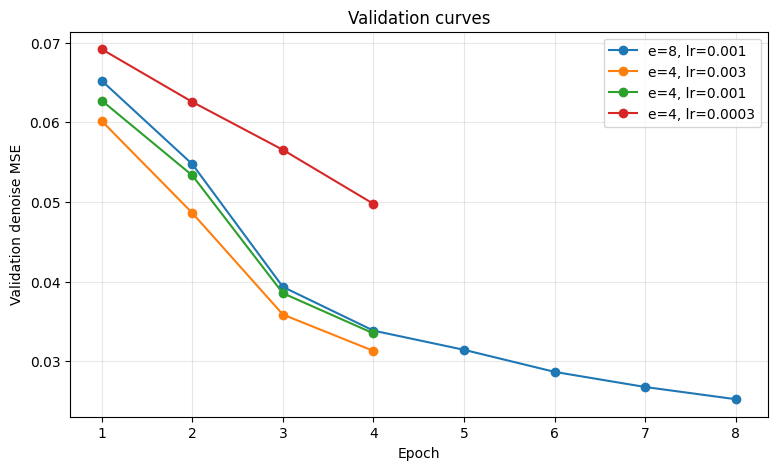

In [16]:
def plot_training_curves(run_ids: List[str]):
    plt.figure(figsize=(9, 5))
    for run_id in run_ids:
        history = ARTIFACTS[run_id]["history"]
        label = run_id.split("|")[-2] + ", " + run_id.split("|")[-1]
        plt.plot(history["epoch"], history["val_denoise_mse"], marker="o", label=label)

    plt.xlabel("Epoch")
    plt.ylabel("Validation denoise MSE")
    plt.title("Validation curves")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


hyperparameter_run_ids = results_df[results_df["study"] == "hyperparameters"]["run_id"].drop_duplicates().tolist()
plot_training_curves(hyperparameter_run_ids)

uniform +/-0.45|h=512x256|z=32|e=4|lr=0.001


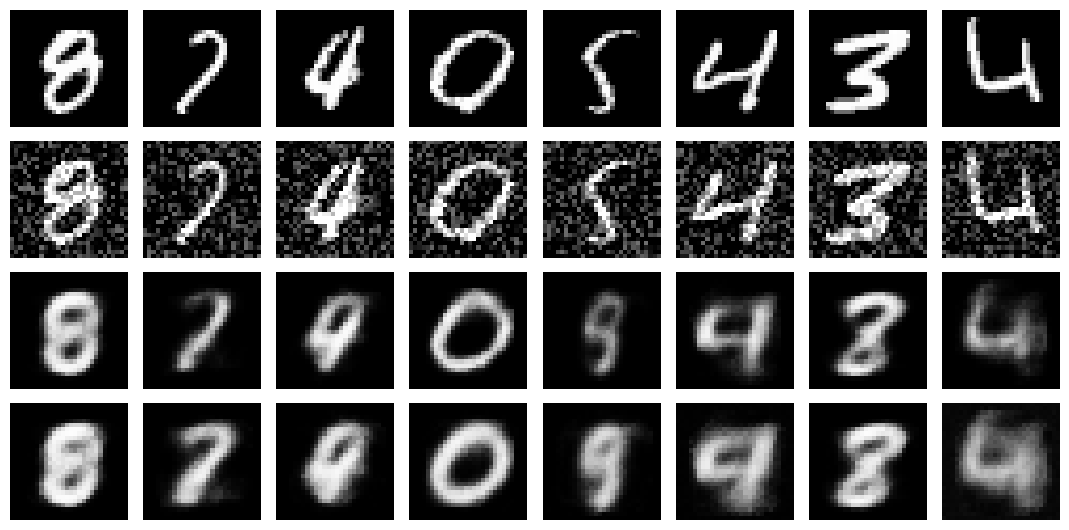

gaussian sigma=0.35|h=512x256|z=32|e=4|lr=0.001


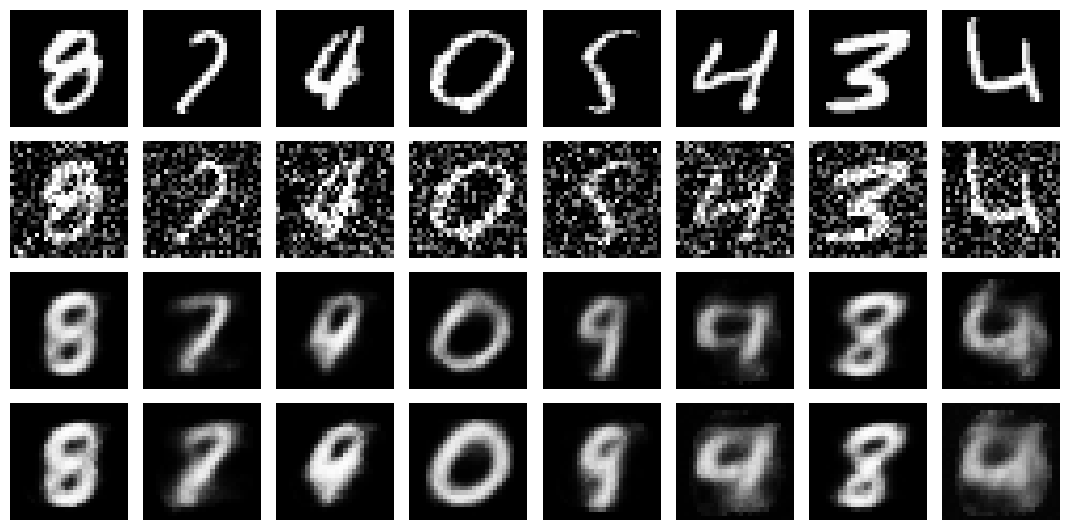

spots 2x7|h=512x256|z=32|e=4|lr=0.001


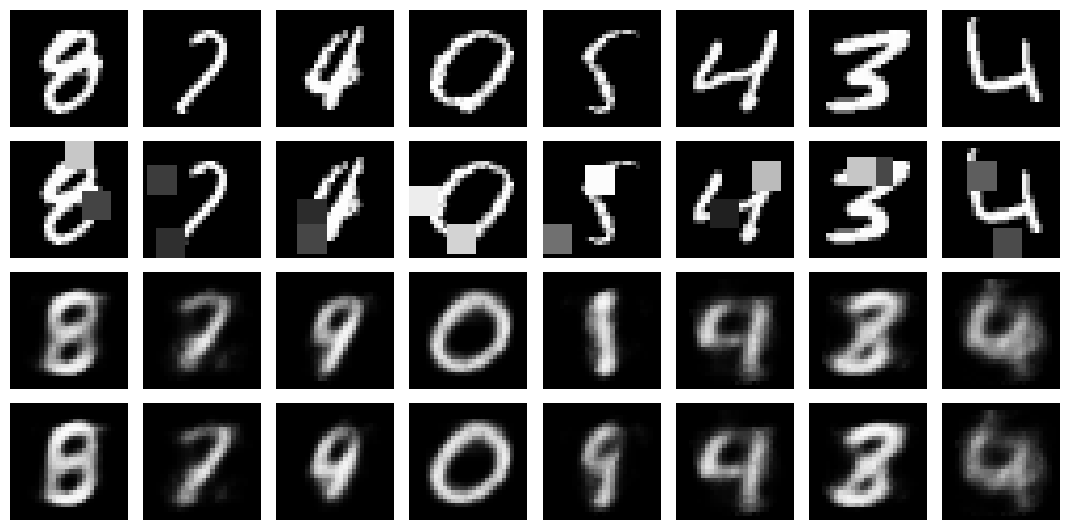

In [17]:
@torch.no_grad()
def visualize_reconstructions(run_id: str, loader: DataLoader = test_loader, n: int = 8):
    artifact = ARTIFACTS[run_id]
    model = artifact["model"]
    noise_cfg = artifact["noise_cfg"]
    model.eval()

    clean, labels = next(iter(loader))
    clean = clean[:n].to(DEVICE)
    noisy = add_noise(clean, noise_cfg)
    denoised = model(noisy)
    clean_reconstructed = model(clean)

    print(run_id)
    plot_tensor_grid([
        ("clean", clean),
        ("noisy", noisy),
        ("denoised", denoised),
        ("clean AE", clean_reconstructed),
    ], n=n, figsize_per_image=1.35)


for noise_name in NOISE_CONFIGS:
    part = results_df[(results_df["study"] == "noise_type") & (results_df["experiment"] == noise_name)]
    run_id = part.iloc[0]["run_id"]
    visualize_reconstructions(run_id, n=8)

Best run: gaussian sigma=0.35|h=512x256|z=32|e=8|lr=0.001
study             hyperparameters
experiment      epochs_8_lr_0.001
denoise_mse              0.024452
denoise_psnr            16.116827
denoise_ssim             0.838872
clean_mse                0.033299
clean_psnr              14.775716
mse_gain_%              60.780697
Name: 4, dtype: object
gaussian sigma=0.35|h=512x256|z=32|e=8|lr=0.001


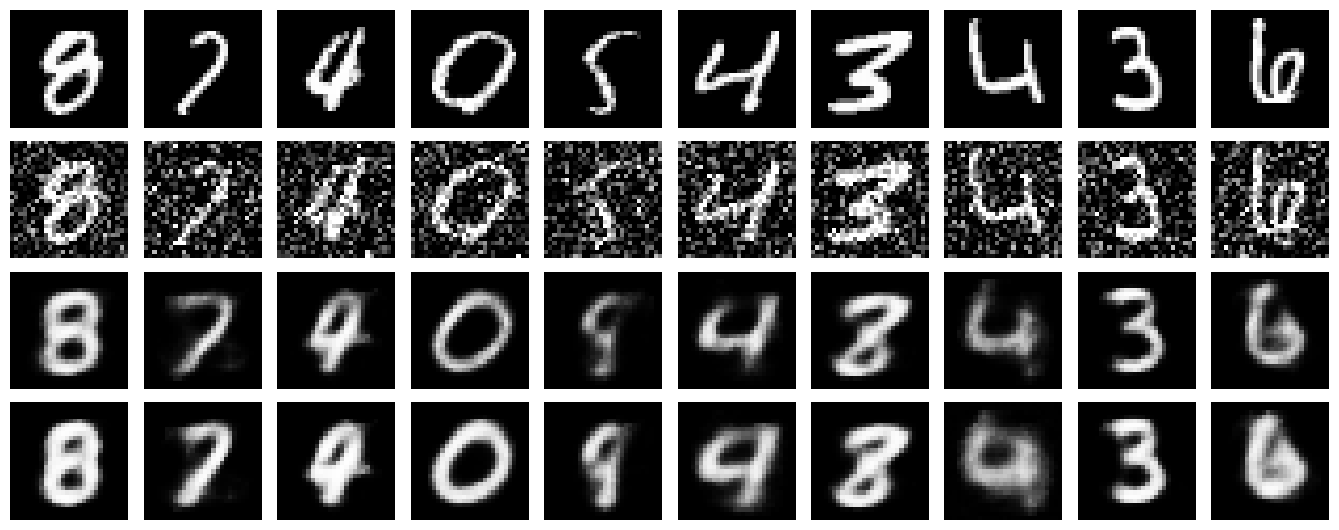

In [18]:
best_row = results_df.sort_values("denoise_mse").iloc[0]
best_run_id = best_row["run_id"]
best_artifact = ARTIFACTS[best_run_id]
best_model = best_artifact["model"]

print("Best run:", best_run_id)
print(best_row[["study", "experiment", "denoise_mse", "denoise_psnr", "denoise_ssim", "clean_mse", "clean_psnr", "mse_gain_%"]])

visualize_reconstructions(best_run_id, n=10)

Latent tensor: torch.Size([2000, 32])
Latent mean/std: -0.05252214893698692 2.1166954040527344


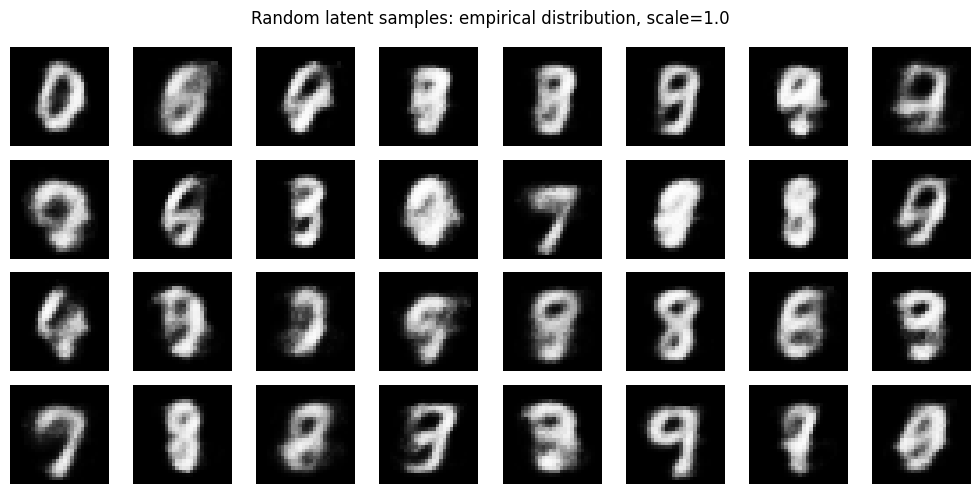

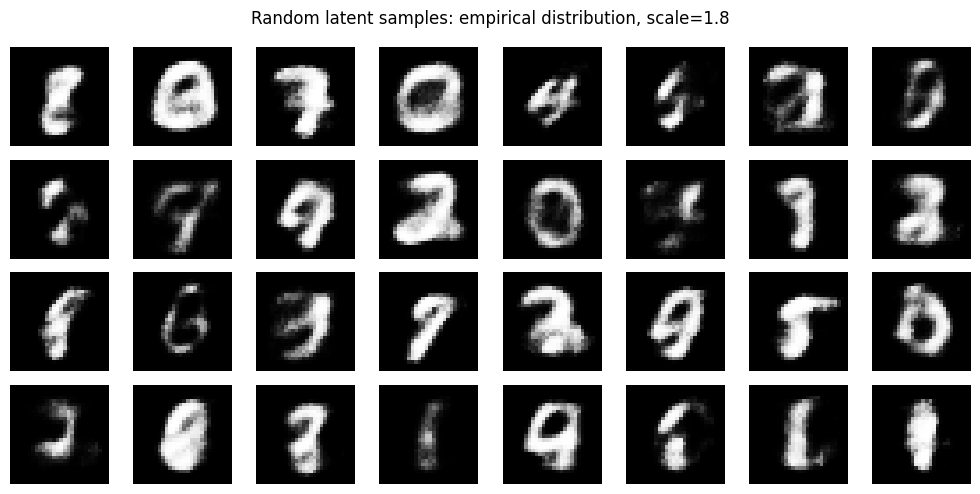

In [19]:
@torch.no_grad()
def collect_latents(model: DenseAutoencoder, loader: DataLoader, max_batches: int = 20) -> torch.Tensor:
    model.eval()
    latents = []
    for batch_idx, (clean, _) in enumerate(loader):
        if batch_idx >= max_batches:
            break
        clean = clean.to(DEVICE)
        latents.append(model.encode(clean).detach().cpu())
    return torch.cat(latents, dim=0)


@torch.no_grad()
def generate_from_random_latents(model: DenseAutoencoder, reference_latents: torch.Tensor, n: int = 32, scale: float = 1.0) -> torch.Tensor:
    model.eval()
    mean = reference_latents.mean(dim=0).to(DEVICE)
    std = reference_latents.std(dim=0).clamp_min(1e-3).to(DEVICE)
    z = mean + torch.randn(n, mean.numel(), device=DEVICE) * std * scale
    return model.decode(z).detach().cpu()


def plot_generated(images: torch.Tensor, title: str, ncols: int = 8):
    n = images.size(0)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.25 * ncols, 1.25 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)

    for idx in range(nrows * ncols):
        ax = axes[idx // ncols, idx % ncols]
        ax.axis("off")
        if idx < n:
            ax.imshow(images[idx].squeeze(0), cmap="gray", vmin=0.0, vmax=1.0)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


latents = collect_latents(best_model, test_loader)
print("Latent tensor:", latents.shape)
print("Latent mean/std:", float(latents.mean()), float(latents.std()))

generated_close = generate_from_random_latents(best_model, latents, n=32, scale=1.0)
generated_wide = generate_from_random_latents(best_model, latents, n=32, scale=1.8)

plot_generated(generated_close, "Random latent samples: empirical distribution, scale=1.0")
plot_generated(generated_wide, "Random latent samples: empirical distribution, scale=1.8")

Interpolating labels: 8 -> 7


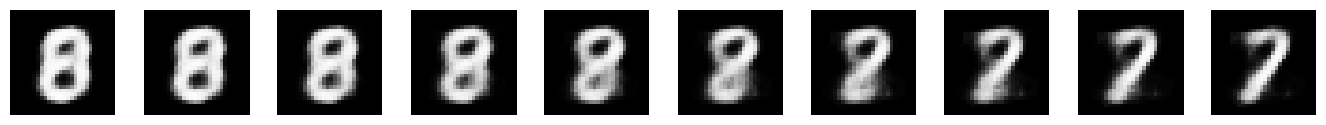

In [20]:
@torch.no_grad()
def visualize_latent_interpolation(model: DenseAutoencoder, loader: DataLoader, steps: int = 10):
    model.eval()
    clean, labels = next(iter(loader))
    clean = clean.to(DEVICE)

    first = clean[0:1]
    second = clean[1:2]
    z_first = model.encode(first)
    z_second = model.encode(second)

    alphas = torch.linspace(0, 1, steps, device=DEVICE).view(-1, 1)
    z = (1 - alphas) * z_first + alphas * z_second
    decoded = model.decode(z)

    print("Interpolating labels:", int(labels[0]), "->", int(labels[1]))
    plot_tensor_grid([("interp", decoded)], n=steps, figsize_per_image=1.35)


visualize_latent_interpolation(best_model, test_loader, steps=10)

In [21]:
summary_cols = ["study", "experiment", "noise", "latent_dim", "hidden_dims", "epochs", "lr", "denoise_mse", "denoise_psnr", "clean_mse", "mse_gain_%"]

print("Best experiment for each study:")
best_by_study = results_df.sort_values("denoise_mse").groupby("study", as_index=False).first()
display(best_by_study[summary_cols].style.format({
    "lr": "{:.0e}",
    "denoise_mse": "{:.5f}",
    "denoise_psnr": "{:.2f}",
    "clean_mse": "{:.5f}",
    "mse_gain_%": "{:.1f}",
}))

print("Overall best:")
display(results_df.sort_values("denoise_mse").head(1)[summary_cols].style.format({
    "lr": "{:.0e}",
    "denoise_mse": "{:.5f}",
    "denoise_psnr": "{:.2f}",
    "clean_mse": "{:.5f}",
    "mse_gain_%": "{:.1f}",
}))

Best experiment for each study:


,study,experiment,noise,latent_dim,hidden_dims,epochs,lr,denoise_mse,denoise_psnr,clean_mse,mse_gain_%
0,architecture,shallow_256,gaussian sigma=0.35,32,"(256,)",4,1e-03,0.02858,15.44,0.04655,54.3
1,hyperparameters,epochs_8_lr_0.001,gaussian sigma=0.35,32,"(512, 256)",8,1e-03,0.02445,16.12,0.03330,60.8
2,latent_dim,latent_16,gaussian sigma=0.35,16,"(512, 256)",4,1e-03,0.03249,14.88,0.04037,48.1
3,noise_type,uniform,uniform +/-0.45,32,"(512, 256)",4,1e-03,0.03073,15.12,0.04393,13.9


Overall best:


,study,experiment,noise,latent_dim,hidden_dims,epochs,lr,denoise_mse,denoise_psnr,clean_mse,mse_gain_%
4,hyperparameters,epochs_8_lr_0.001,gaussian sigma=0.35,32,"(512, 256)",8,1e-03,0.02445,16.12,0.03330,60.8
